# US 18

In [1]:
## Importar Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load and prepare holdings data for actor-company pair analysis.
holdings_df = pd.read_csv("../Dados/dataset2_holdings.csv")
rows_before = len(holdings_df)

required_columns = [
    "agent_id",
    "company_NIF",
    "total_value_in_stocks",
    "declaration_date",
]

analysis_df = holdings_df.copy()
analysis_df["declaration_date"] = pd.to_datetime(analysis_df["declaration_date"], errors="coerce")
analysis_df["total_value_in_stocks"] = pd.to_numeric(
    analysis_df["total_value_in_stocks"], errors="coerce"
)
analysis_df["agent_id"] = analysis_df["agent_id"].astype(str).str.strip()
analysis_df["company_NIF"] = analysis_df["company_NIF"].astype(str).str.strip()

analysis_df = analysis_df.dropna(
    subset=["agent_id", "company_NIF", "declaration_date", "total_value_in_stocks"]
).copy()

analysis_df = (
    analysis_df.groupby(["agent_id", "company_NIF", "declaration_date"], as_index=False)["total_value_in_stocks"]
    .sum()
    .sort_values(["agent_id", "company_NIF", "declaration_date"])
    .reset_index(drop=True)
)
analysis_df["pair_label"] = analysis_df["agent_id"] + " | " + analysis_df["company_NIF"]

pair_summary = (
    analysis_df.groupby(["agent_id", "company_NIF", "pair_label"], as_index=False)
    .agg(
        start_date=("declaration_date", "first"),
        end_date=("declaration_date", "last"),
        initial_value=("total_value_in_stocks", "first"),
        recent_value=("total_value_in_stocks", "last"),
        observations=("total_value_in_stocks", "size"),
    )
)

pair_summary["increase"] = pair_summary["recent_value"] - pair_summary["initial_value"]
pair_summary["increase_pct"] = np.where(
    pair_summary["initial_value"] != 0,
    (pair_summary["increase"] / pair_summary["initial_value"]) * 100,
    np.nan,
)

top10_pairs = (
    pair_summary.sort_values(
        by=["increase", "recent_value", "agent_id", "company_NIF"],
        ascending=[False, False, True, True],
    )
    .head(10)
    .reset_index(drop=True)
)

print(f"Total rows loaded: {rows_before}")
print(f"Rows after cleaning and daily aggregation: {len(analysis_df)}")
print(f"Unique actor-company pairs analyzed: {pair_summary.shape[0]}")
print()

top10_display = top10_pairs[[
    "pair_label",
    "initial_value",
    "recent_value",
    "increase",
    "increase_pct",
    "start_date",
    "end_date",
    "observations",
]].copy()
top10_display["start_date"] = top10_display["start_date"].dt.date
top10_display["end_date"] = top10_display["end_date"].dt.date
top10_display[["initial_value", "recent_value", "increase", "increase_pct"]] = (
    top10_display[["initial_value", "recent_value", "increase", "increase_pct"]].round(2)
)

print("Top 10 actor-company pairs by increase in stock value:")
print(top10_display)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
    }
)

Total rows loaded: 953
Rows after cleaning and daily aggregation: 952
Unique actor-company pairs analyzed: 267

Top 10 actor-company pairs by increase in stock value:
           pair_label  initial_value  recent_value   increase  increase_pct  \
0  A00049 | 100000096       27081.42     322836.95  295755.53       1092.10   
1  A00054 | 100000048       94531.47     388940.59  294409.12        311.44   
2  A00074 | 100000084      169621.56     450026.28  280404.72        165.31   
3  A00095 | 100000055       95466.62     370048.28  274581.66        287.62   
4  A00051 | 100000080       41381.16     311297.68  269916.52        652.27   
5  A00092 | 100000073       63183.01     318368.22  255185.21        403.88   
6  A00059 | 100000037      109034.83     347936.12  238901.29        219.11   
7  A00036 | 100000071       72312.47     308986.13  236673.66        327.29   
8  A00068 | 100000000      133759.03     367783.38  234024.35        174.96   
9  A00006 | 100000003       82267.19     31

### Graph 1: Top 10 Increases by Actor-Company Pair

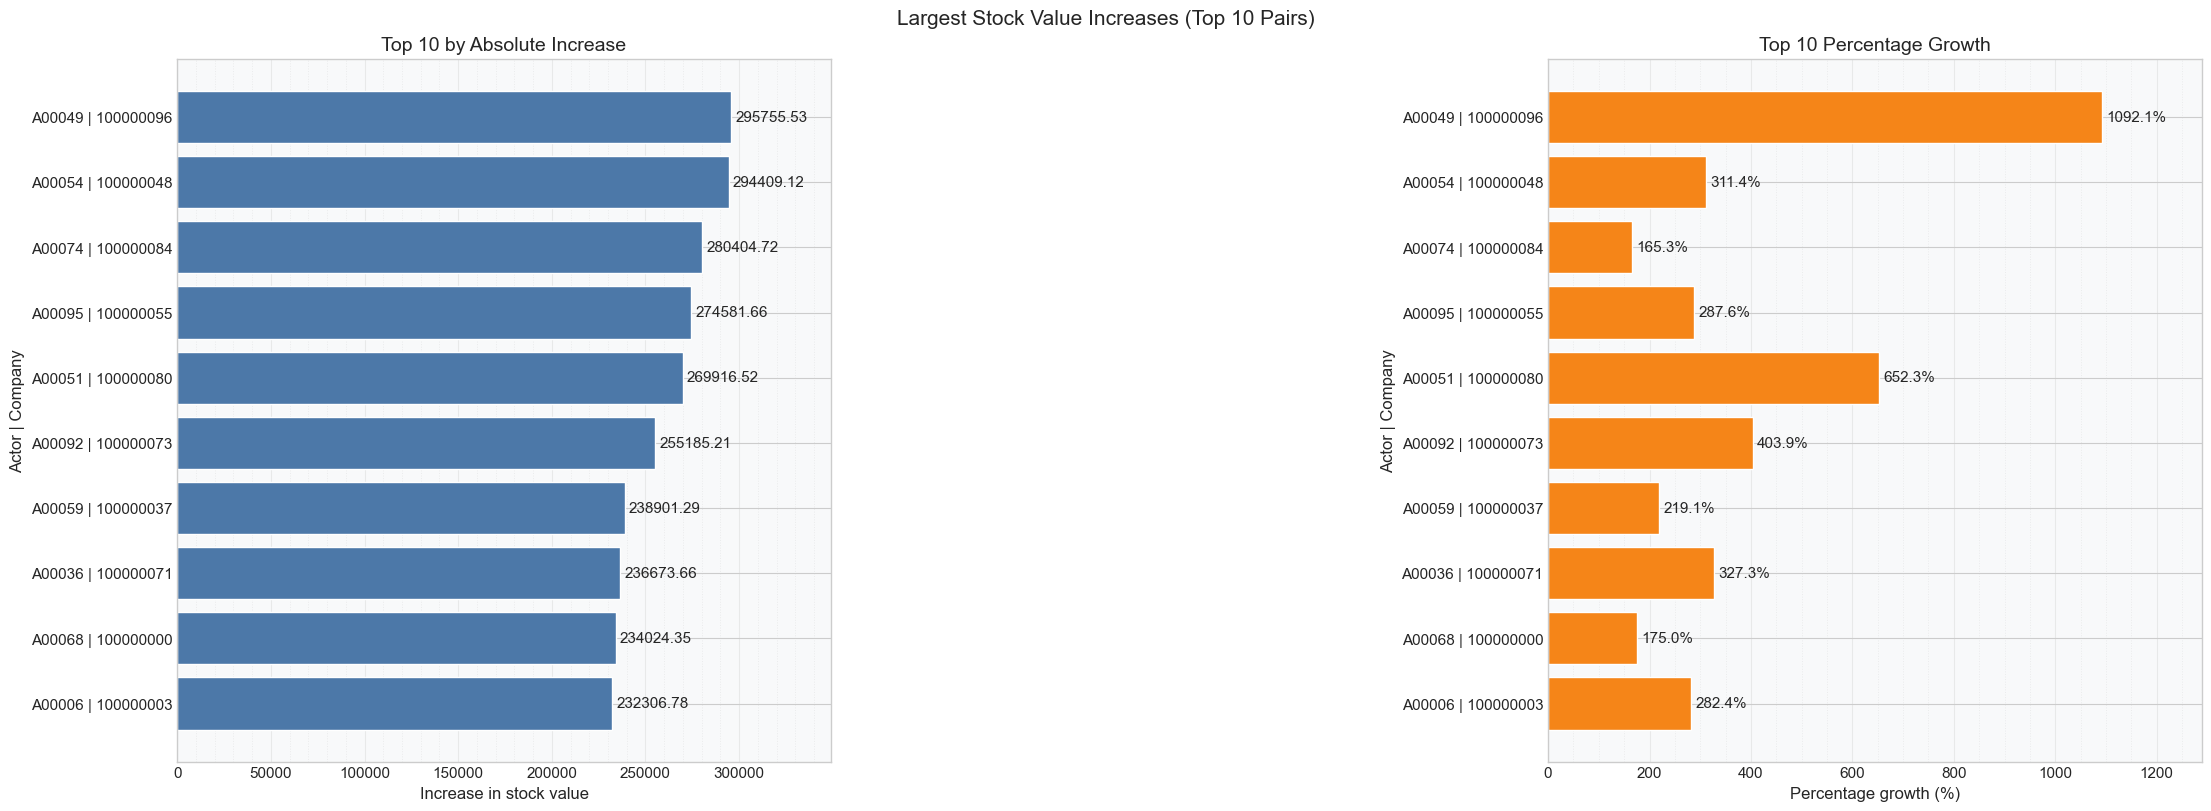

In [3]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(22, 8),
    gridspec_kw={"wspace": 0.50},
    constrained_layout=True,
)

ranking_plot_df = top10_pairs.sort_values("increase", ascending=True)

bars_abs = ax1.barh(
    ranking_plot_df["pair_label"],
    ranking_plot_df["increase"],
    color="#4C78A8",
)
abs_max = ranking_plot_df["increase"].max()
ax1.set_xlim(0, abs_max * 1.18)
ax1.set_title("Top 10 by Absolute Increase")
ax1.set_xlabel("Increase in stock value")
ax1.set_ylabel("Actor | Company")
ax1.set_axisbelow(True)
ax1.minorticks_on()
ax1.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax1.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax1.bar_label(bars_abs, fmt="%.2f", padding=3)

bars_pct = ax2.barh(
    ranking_plot_df["pair_label"],
    ranking_plot_df["increase_pct"],
    color="#F58518",
)
pct_max = ranking_plot_df["increase_pct"].max()
ax2.set_xlim(0, pct_max * 1.18)
ax2.set_title("Top 10 Percentage Growth")
ax2.set_xlabel("Percentage growth (%)")
ax2.set_ylabel("Actor | Company")
ax2.set_axisbelow(True)
ax2.minorticks_on()
ax2.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax2.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax2.bar_label(bars_pct, fmt="%.1f%%", padding=3)

fig.suptitle("Largest Stock Value Increases (Top 10 Pairs)", fontsize=15)
plt.show()

### Graph 2: Evolution Over Time for the Top 10 Pairs

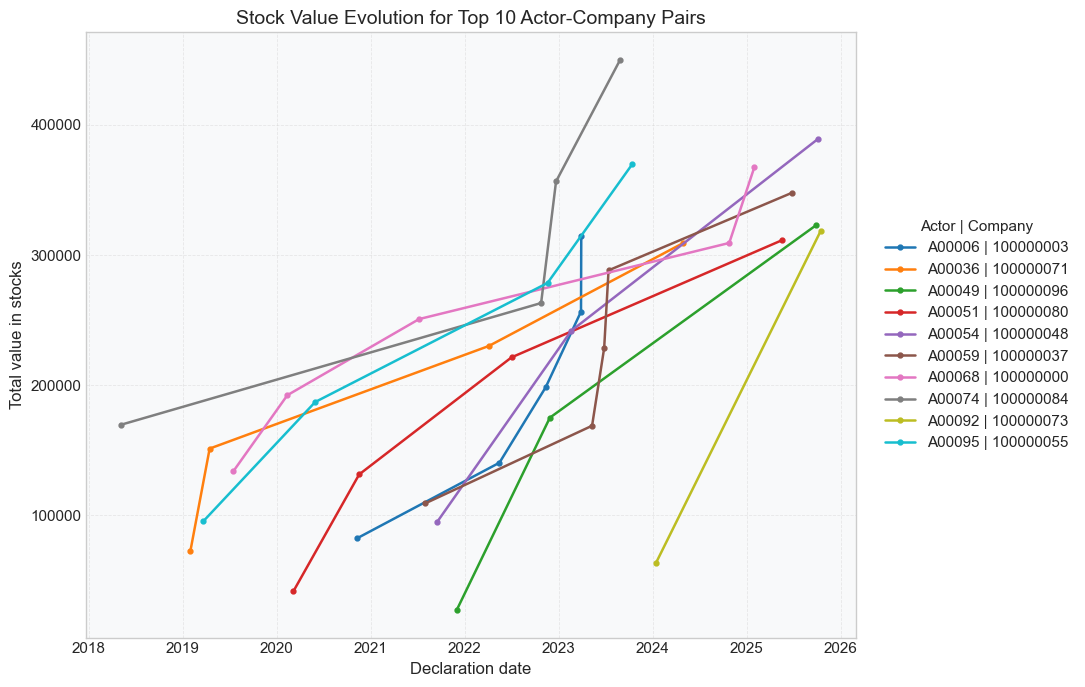

In [4]:
selected_pairs = top10_pairs[["agent_id", "company_NIF", "pair_label"]].copy()
evolution_df = analysis_df.merge(
    selected_pairs, on=["agent_id", "company_NIF", "pair_label"], how="inner"
)

fig, ax = plt.subplots(figsize=(11, 7))

for pair_label, group in evolution_df.groupby("pair_label"):
    group = group.sort_values("declaration_date")
    ax.plot(
        group["declaration_date"],
        group["total_value_in_stocks"],
        marker="o",
        linewidth=1.8,
        markersize=3.5,
        label=pair_label,
    )

ax.set_title("Stock Value Evolution for Top 10 Actor-Company Pairs")
ax.set_xlabel("Declaration date")
ax.set_ylabel("Total value in stocks")
ax.grid(axis="both", linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend(title="Actor | Company", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [5]:
top_pair = top10_pairs.iloc[0]
top_pair_pct = top10_pairs.loc[top10_pairs["increase_pct"].idxmax()]
median_increase = top10_pairs["increase"].median()
median_increase_pct = top10_pairs["increase_pct"].median()

trend_flags = []
for _, pair in top10_pairs.iterrows():
    mask = (analysis_df["agent_id"] == pair["agent_id"]) & (
        analysis_df["company_NIF"] == pair["company_NIF"]
    )
    pair_series = analysis_df.loc[mask].sort_values("declaration_date")["total_value_in_stocks"]
    trend_flags.append(pair_series.is_monotonic_increasing)

monotonic_count = int(sum(trend_flags))
volatile_count = int(len(trend_flags) - monotonic_count)

print("Interpretation:")
print(
    f"- The pair with the largest absolute increase is '{top_pair['pair_label']}', "
    f"rising from {top_pair['initial_value']:.2f} to {top_pair['recent_value']:.2f} "
    f"(increase of {top_pair['increase']:.2f})."
 )
print(
    f"- The pair with the largest percentage growth is '{top_pair_pct['pair_label']}' "
    f"with {top_pair_pct['increase_pct']:.2f}% growth."
 )
print(
    f"- The median increase among the top 10 pairs is {median_increase:.2f}, "
    f"and the median percentage growth is {median_increase_pct:.2f}%."
 )
print(
    f"- Within the top 10, {monotonic_count} pairs show a monotonic increase over time, "
    f"while {volatile_count} show at least one decline between declarations."
 )
print("- Pair labels use IDs only (agent_id and company_NIF), as actor/company names are not in the source data.")

Interpretation:
- The pair with the largest absolute increase is 'A00049 | 100000096', rising from 27081.42 to 322836.95 (increase of 295755.53).
- The pair with the largest percentage growth is 'A00049 | 100000096' with 1092.10% growth.
- The median increase among the top 10 pairs is 262550.86, and the median percentage growth is 299.53%.
- Within the top 10, 10 pairs show a monotonic increase over time, while 0 show at least one decline between declarations.
- Pair labels use IDs only (agent_id and company_NIF), as actor/company names are not in the source data.
